In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')

import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [3]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [4]:
domain_2 = 'GRp'

In [5]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
# sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [6]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [7]:
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_TTZ= xr.open_dataset(sourceData_1+fileNameF).isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [8]:
variable='RF'

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_RF= xr.open_dataset(sourceData_1+fileNameF).RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [9]:
variable='SF'

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_SF= xr.open_dataset(sourceData_1+fileNameF).SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [10]:
variable='ME' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_ME= xr.open_dataset(sourceData_1+fileNameF).ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]

In [11]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_SMB= xr.open_dataset(sourceData_1+fileNameF).SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

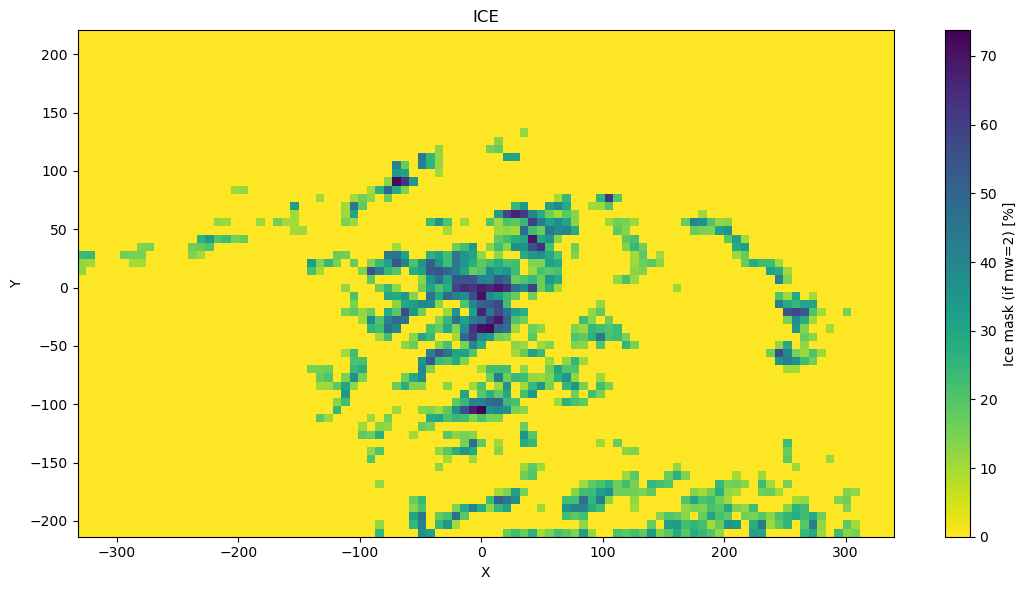

In [12]:
fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1])  # 2 rows, 2 columns

# Large plot on the left (occupies both rows of first column)
ax_main = fig.add_subplot(gs[:, 0])
ds_ICE.plot(cmap='viridis_r', ax=ax_main)
ax_main.set_title("ICE")

# # Two smaller plots on the right column
# ax1 = fig.add_subplot(gs[0, 1])
# ds_ICE.plot(cmap='viridis_r',ax=ax1)
# ax1.set_title("0% ice (if green)")

# ax2 = fig.add_subplot(gs[1, 1])
# ds_ICE100.plot(cmap='viridis_r',ax=ax2)
# ax2.set_title("100% ice (does not exist)")

plt.tight_layout()
plt.show()

In [13]:
##Fedchenko area
#lon
w=24 #(bot)
x=34

#lat
y=40
z=52

/tmp/ipykernel_207763/2430188102.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(ds_lon[w:x,y:z], ds_lat[w:x,y:z],ds_ICE[w:x,y:z],shading='auto',vmin=0, vmax=100)


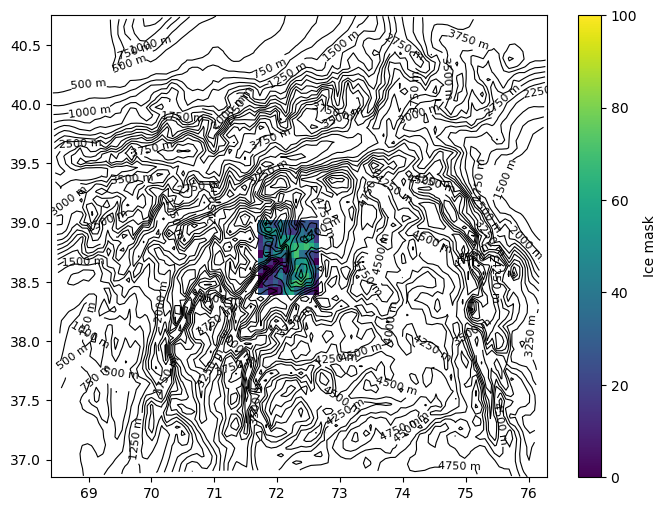

In [14]:
levels = np.arange(500, 7500, 250)  # Niveaux tous les 1000m 

fig, ax = plt.subplots(figsize=(8,6))

m = ax.pcolormesh(ds_lon[w:x,y:z], ds_lat[w:x,y:z],ds_ICE[w:x,y:z],shading='auto',vmin=0, vmax=100)                   
contours = ax.contour(ds_lon, ds_lat,ds_SH, levels=levels, colors='black', linewidths=0.8)

ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         


cbar = fig.colorbar(m, ax=ax, orientation='vertical')
cbar.set_label("Ice mask")

plt.show()

In [15]:
ds_Fed = ds_TTZ[:,w:x,y:z]
ds_ICE_Fed = ds_ICE[w:x,y:z]
ds_Fed_lon = ds_lon[w:x,y:z]
ds_Fed_lat = ds_lat[w:x,y:z]
ds_Fed_SH = ds_SH[w:x,y:z]

In [16]:
ds_ICE_Fed_expanded = ds_ICE_Fed.expand_dims({"time": ds_Fed.time}).transpose("time", "Y", "X")

In [17]:
ice_threshold = 32
dsF_glacier = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_Fed, np.nan)
dsF_lon_glacier = xr.where(ds_ICE_Fed>ice_threshold, ds_Fed_lon, np.nan)
dsF_lat_glacier = xr.where(ds_ICE_Fed>ice_threshold, ds_Fed_lat, np.nan)
dsF_lat_SH = xr.where(ds_ICE_Fed>ice_threshold, ds_Fed_SH, np.nan)

In [18]:
print('min atitude of selected Fechenko glacier area: ', ds_Fed_SH.min())
print('max atitude of selected Fechenko glacier area: ', ds_Fed_SH.max())
print('mean atitude of selected Fechenko glacier area: ', ds_Fed_SH.mean(skipna=True))
count = np.count_nonzero(~np.isnan(ds_Fed_SH))
count_all = ds_Fed_SH.size
print('mean atitude of selected Fechenko glacier area: ',count)
print('mean atitude of selected Fechenko glacier area: ',count_all)

min atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(2857.7615, dtype=float32)
max atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(5668.944, dtype=float32)
mean atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(4452.6855, dtype=float32)
mean atitude of selected Fechenko glacier area:  120
mean atitude of selected Fechenko glacier area:  120


/tmp/ipykernel_207763/1737662921.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = axes[i].pcolormesh(
/tmp/ipykernel_207763/1737662921.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = axes[i].pcolormesh(
/tmp/ipykernel_207763/1737662921.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = axes[i].pcolormesh(
/tmp/ipykernel_207763/1737662921.py:13: UserWarning:

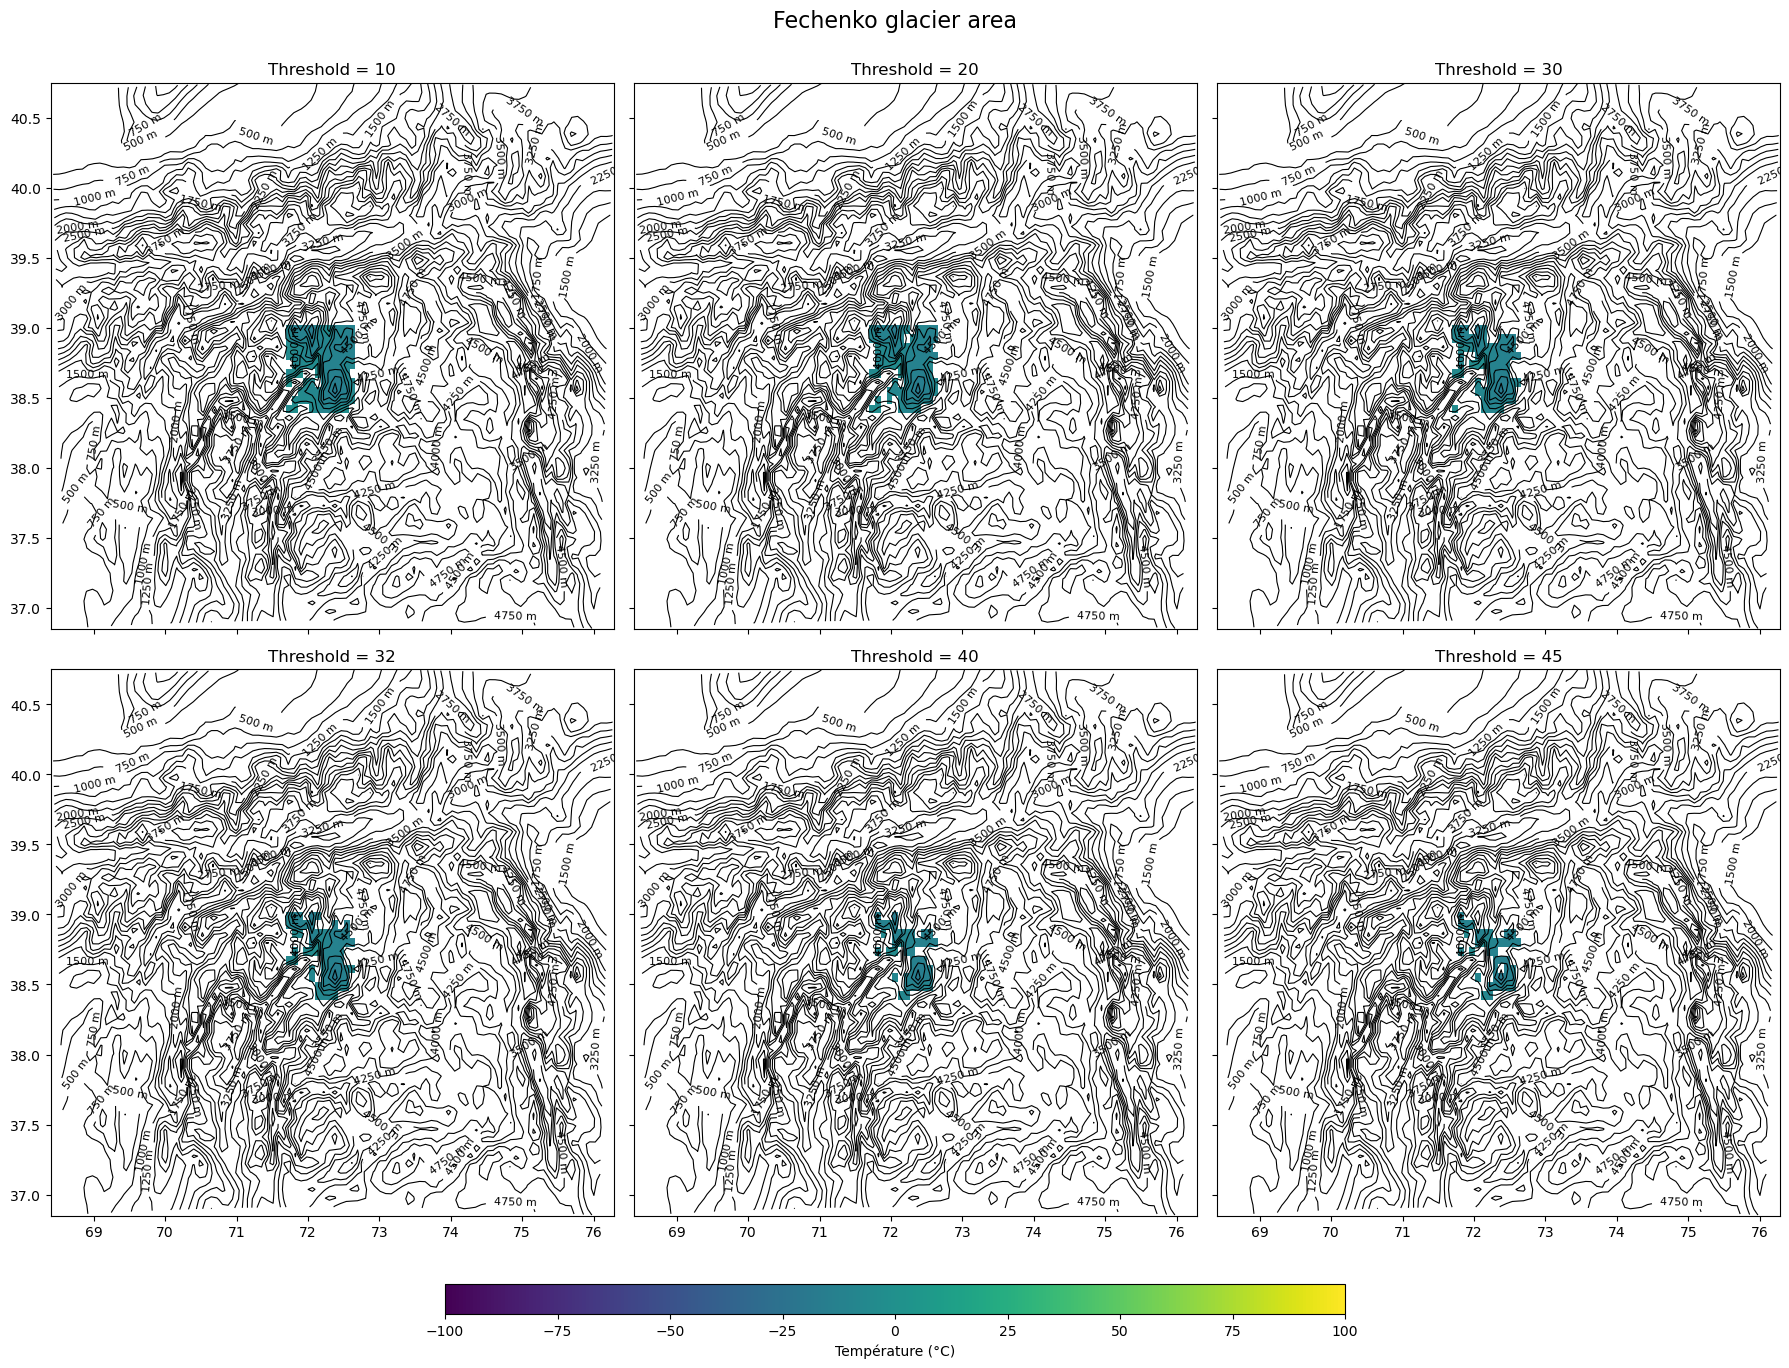

In [19]:
thresholds = [10, 20, 30, 32, 40, 45]

levels = np.arange(500, 7500, 250)

fig, axes = plt.subplots(2, 3, figsize=(18, 15), sharex=True, sharey=True)
axes = axes.flatten()

for i, thr in enumerate(thresholds):
    dsF_glacier = xr.where(ds_ICE_Fed_expanded > thr, ds_Fed, np.nan)
    dsF_lon_glacier = xr.where(ds_ICE_Fed > thr, ds_Fed_lon, np.nan)
    dsF_lat_glacier = xr.where(ds_ICE_Fed > thr, ds_Fed_lat, np.nan)
    
    m = axes[i].pcolormesh(
        ds_Fed_lon, ds_Fed_lat,
        dsF_glacier.mean(dim="time"),
        shading='auto', vmin=-100, vmax=100
    )
    
    contours = axes[i].contour(
        ds_lon, ds_lat, ds_SH,
        levels=levels, colors='black', linewidths=0.8
    )
    axes[i].clabel(contours, inline=True, fontsize=8, fmt='%d m')
    
    axes[i].set_title(f"Threshold = {thr}")
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  
cbar = fig.colorbar(m, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Température (°C)")

fig.suptitle("Fechenko glacier area", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.12, 1, 0.95]) 
plt.show()

In [20]:
#localiser la cellule unique >5500 m absl
ice_threshold = 32
elev_threshold = 5500
dsF_glacier = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_Fed, np.nan)
dsF_lon_glacier = xr.where(ds_ICE_Fed>ice_threshold, ds_Fed_lon, np.nan)
dsF_lat_glacier = xr.where(ds_ICE_Fed>ice_threshold, ds_Fed_lat, np.nan)
dsF_lat_SH = xr.where(ds_ICE_Fed>ice_threshold, ds_Fed_SH, np.nan)

### ANALYSES on the GLACIER AREA

In [21]:
ds_ME_temp = ds_ME[:,w:x,y:z]
ds_TTZ_temp = ds_TTZ[:,w:x,y:z]
ds_SMB_temp = ds_SMB[:,w:x,y:z]
ds_RF_temp = ds_RF[:,w:x,y:z]
ds_SF_temp = ds_SF[:,w:x,y:z]

ds_ICE_temp = ds_ICE[w:x,y:z]

ds_lon_temp = ds_lon[w:x,y:z]
ds_lat_temp = ds_lat[w:x,y:z]
ds_SH_temp = ds_SH[w:x,y:z]

In [22]:
ds_ICE_Fed_expanded = ds_ICE_Fed.expand_dims({"time": ds_Fed.time}).transpose("time", "Y", "X")

In [23]:
ice_threshold = 32
ds_ME_Fed = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_ME_temp, np.nan)
ds_TTZ_Fed = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_TTZ_temp, np.nan)
ds_SMB_Fed = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_SMB_temp, np.nan) 
ds_RF_Fed = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_RF_temp, np.nan)
ds_SF_Fed = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_SF_temp, np.nan)

ds_lon_Fed = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_lon_temp, np.nan)
ds_lat_Fed = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_lat_temp, np.nan)
ds_SH_Fed = xr.where(ds_ICE_Fed_expanded>ice_threshold, ds_SH_temp, np.nan)

In [24]:
ds_ME_Fed_flat = ds_ME_Fed.sum(dim='time').values.flatten() 
ds_SH_Fed_flat = ds_SH_Fed.mean(dim='time').values.flatten()

In [25]:
#Exclude the upper z-level integrating only 1 grid cell:
max_elev_bin=5500
elev_bins = np.arange(0, np.nanmax(max_elev_bin) + 250, 250)

#Consider all altitudinal level possible::
#elev_bins = np.arange(0, np.nanmax(ds_SH_Fed_flat) + 250, 250)
elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2

In [26]:
elev_bins

array([   0,  250,  500,  750, 1000, 1250, 1500, 1750, 2000, 2250, 2500,
       2750, 3000, 3250, 3500, 3750, 4000, 4250, 4500, 4750, 5000, 5250,
       5500])

In [27]:
elev_bins = ([   0.,  250.,  500.,  750., 1000., 1250., 1500., 1750., 2000.,
       2250., 2500., 2750., 3000., 3250., 3500., 3750., 4000., 4250.,
       4500., 4750., 5000., 5250., 5500.])

In [28]:
elev_bin_labels

array([ 125.,  375.,  625.,  875., 1125., 1375., 1625., 1875., 2125.,
       2375., 2625., 2875., 3125., 3375., 3625., 3875., 4125., 4375.,
       4625., 4875., 5125., 5375.])

In [29]:
count = np.sum(ds_SH_Fed_flat > 5000)
count

np.int64(20)

In [30]:
#1980-1989
ds_ME_Fed_1980=ds_ME_Fed.sel(time=slice(str(iyr),str(iyr+9)))
ds_SMB_Fed_1980=ds_SMB_Fed.sel(time=slice(str(iyr),str(iyr+9)))
ds_TTZ_Fed_1980=ds_TTZ_Fed.sel(time=slice(str(iyr),str(iyr+9)))
ds_RF_Fed_1980=ds_RF_Fed.sel(time=slice(str(iyr),str(iyr+9)))
ds_SF_Fed_1980=ds_SF_Fed.sel(time=slice(str(iyr),str(iyr+9)))

ds_ME_Fed_1980_season = ds_ME_Fed_1980.groupby('time.season').mean(dim='time')
ds_SMB_Fed_1980_season = ds_SMB_Fed_1980.groupby('time.season').mean(dim='time') #SOMME pour le SMB
ds_TTZ_Fed_1980_season = ds_TTZ_Fed_1980.groupby('time.season').mean(dim='time')
ds_RF_Fed_1980_season = ds_RF_Fed_1980.groupby('time.season').mean(dim='time')
ds_SF_Fed_1980_season = ds_SF_Fed_1980.groupby('time.season').mean(dim='time')

In [31]:
#1990-1999
ds_ME_Fed_1990=ds_ME_Fed.sel(time=slice(str(iyr+10),str(iyr+19)))
ds_SMB_Fed_1990=ds_SMB_Fed.sel(time=slice(str(iyr+10),str(iyr+19)))
ds_TTZ_Fed_1990=ds_TTZ_Fed.sel(time=slice(str(iyr+10),str(iyr+19)))
ds_RF_Fed_1990=ds_RF_Fed.sel(time=slice(str(iyr+10),str(iyr+19)))
ds_SF_Fed_1990=ds_SF_Fed.sel(time=slice(str(iyr+10),str(iyr+19)))

ds_ME_Fed_1990_season = ds_ME_Fed_1990.groupby('time.season').mean(dim='time')
ds_SMB_Fed_1990_season = ds_SMB_Fed_1990.groupby('time.season').mean(dim='time')
ds_TTZ_Fed_1990_season = ds_TTZ_Fed_1990.groupby('time.season').mean(dim='time')
ds_RF_Fed_1990_season = ds_RF_Fed_1990.groupby('time.season').mean(dim='time')
ds_SF_Fed_1990_season = ds_SF_Fed_1990.groupby('time.season').mean(dim='time')

In [32]:
#2000-2009
ds_ME_Fed_2000=ds_ME_Fed.sel(time=slice(str(iyr+20),str(iyr+29)))
ds_SMB_Fed_2000=ds_SMB_Fed.sel(time=slice(str(iyr+20),str(iyr+29)))
ds_TTZ_Fed_2000=ds_TTZ_Fed.sel(time=slice(str(iyr+20),str(iyr+29)))
ds_RF_Fed_2000=ds_RF_Fed.sel(time=slice(str(iyr+20),str(iyr+29)))
ds_SF_Fed_2000=ds_SF_Fed.sel(time=slice(str(iyr+20),str(iyr+29)))

ds_ME_Fed_2000_season = ds_ME_Fed_2000.groupby('time.season').mean(dim='time')
ds_SMB_Fed_2000_season = ds_SMB_Fed_2000.groupby('time.season').mean(dim='time')
ds_TTZ_Fed_2000_season = ds_TTZ_Fed_2000.groupby('time.season').mean(dim='time')
ds_RF_Fed_2000_season = ds_RF_Fed_2000.groupby('time.season').mean(dim='time')
ds_SF_Fed_2000_season = ds_SF_Fed_2000.groupby('time.season').mean(dim='time')

In [33]:
#2013-2015
ds_ME_Fed_2013=ds_ME_Fed.sel(time=slice(str(iyr+33),str(iyr+35)))
ds_SMB_Fed_2013=ds_SMB_Fed.sel(time=slice(str(iyr+33),str(iyr+35)))
ds_TTZ_Fed_2013=ds_TTZ_Fed.sel(time=slice(str(iyr+33),str(iyr+35)))
ds_RF_Fed_2013=ds_RF_Fed.sel(time=slice(str(iyr+33),str(iyr+35)))
ds_SF_Fed_2013=ds_SF_Fed.sel(time=slice(str(iyr+33),str(iyr+35)))

ds_ME_Fed_2013_season = ds_ME_Fed_2013.groupby('time.season').mean(dim='time')
ds_SMB_Fed_2013_season = ds_SMB_Fed_2013.groupby('time.season').mean(dim='time')
ds_TTZ_Fed_2013_season = ds_TTZ_Fed_2013.groupby('time.season').mean(dim='time')
ds_RF_Fed_2013_season = ds_RF_Fed_2013.groupby('time.season').mean(dim='time')
ds_SF_Fed_2013_season = ds_SF_Fed_2013.groupby('time.season').mean(dim='time')

In [34]:
#2010-2019
ds_ME_Fed_2010=ds_ME_Fed.sel(time=slice(str(iyr+30),str(iyr+39)))
ds_SMB_Fed_2010=ds_SMB_Fed.sel(time=slice(str(iyr+30),str(iyr+39)))
ds_TTZ_Fed_2010=ds_TTZ_Fed.sel(time=slice(str(iyr+30),str(iyr+39)))
ds_RF_Fed_2010=ds_RF_Fed.sel(time=slice(str(iyr+30),str(iyr+39)))
ds_SF_Fed_2010=ds_SF_Fed.sel(time=slice(str(iyr+30),str(iyr+39)))

ds_ME_Fed_2010_season = ds_ME_Fed_2010.groupby('time.season').mean(dim='time')
ds_SMB_Fed_2010_season = ds_SMB_Fed_2010.groupby('time.season').mean(dim='time')
ds_TTZ_Fed_2010_season = ds_TTZ_Fed_2010.groupby('time.season').mean(dim='time')
ds_RF_Fed_2010_season = ds_RF_Fed_2010.groupby('time.season').mean(dim='time')
ds_SF_Fed_2010_season = ds_SF_Fed_2010.groupby('time.season').mean(dim='time')

In [35]:
#2015-2024
ds_ME_Fed_2014=ds_ME_Fed.sel(time=slice(str(fyr-9),str(fyr)))
ds_SMB_Fed_2014=ds_SMB_Fed.sel(time=slice(str(fyr-9),str(fyr)))
ds_TTZ_Fed_2014=ds_TTZ_Fed.sel(time=slice(str(fyr-9),str(fyr)))
ds_RF_Fed_2014=ds_RF_Fed.sel(time=slice(str(fyr-9),str(fyr)))
ds_SF_Fed_2014=ds_SF_Fed.sel(time=slice(str(fyr-9),str(fyr)))

ds_ME_Fed_2014_season = ds_ME_Fed_2014.groupby('time.season').mean(dim='time')
ds_SMB_Fed_2014_season = ds_SMB_Fed_2014.groupby('time.season').mean(dim='time')
ds_TTZ_Fed_2014_season = ds_TTZ_Fed_2014.groupby('time.season').mean(dim='time')
ds_RF_Fed_2014_season = ds_RF_Fed_2014.groupby('time.season').mean(dim='time')
ds_SF_Fed_2014_season = ds_SF_Fed_2014.groupby('time.season').mean(dim='time')

In [36]:
#2019-2024
ds_ME_Fed_2019=ds_ME_Fed.sel(time=slice(str(fyr-5),str(fyr)))
ds_SMB_Fed_2019=ds_SMB_Fed.sel(time=slice(str(fyr-5),str(fyr)))
ds_TTZ_Fed_2019=ds_TTZ_Fed.sel(time=slice(str(fyr-5),str(fyr)))
ds_RF_Fed_2019=ds_RF_Fed.sel(time=slice(str(fyr-5),str(fyr)))
ds_SF_Fed_2019=ds_SF_Fed.sel(time=slice(str(fyr-5),str(fyr)))

ds_ME_Fed_2019_season = ds_ME_Fed_2019.groupby('time.season').mean(dim='time')
ds_SMB_Fed_2019_season = ds_SMB_Fed_2019.groupby('time.season').mean(dim='time')
ds_TTZ_Fed_2019_season = ds_TTZ_Fed_2019.groupby('time.season').mean(dim='time')
ds_RF_Fed_2019_season = ds_RF_Fed_2019.groupby('time.season').mean(dim='time')
ds_SF_Fed_2019_season = ds_SF_Fed_2019.groupby('time.season').mean(dim='time')

### SF et RF

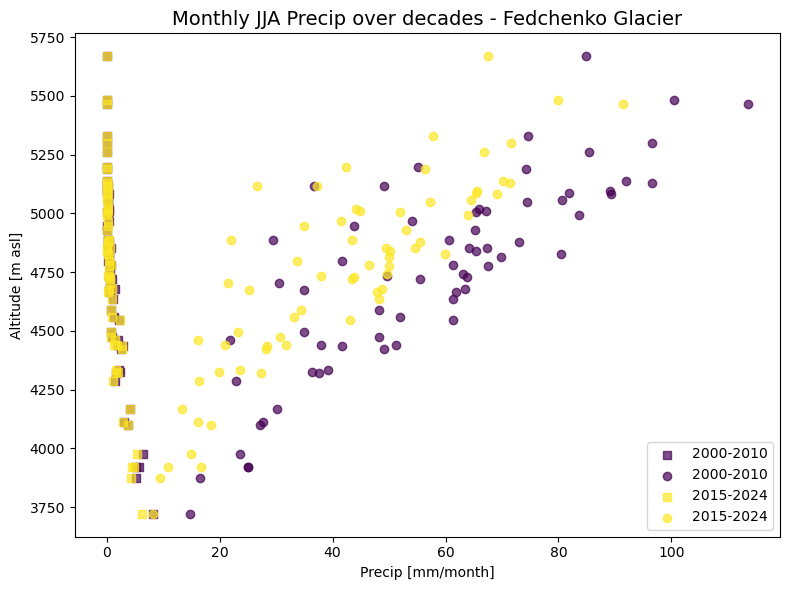

<Figure size 640x480 with 0 Axes>

In [37]:
seas = 'JJA'

plotname = f'{seas}_alti_precip_MAR_GRp'

ds_SH_Fed_flat = ds_SH_Fed.mean(dim='time').values.flatten()

decade = ["2000-2010", "2015-2024"]
param = ['2000','2014']

ds_RF_Fed_dic = {
    "2000": ds_RF_Fed_2000_season.sel(season=seas),
    "2014": ds_RF_Fed_2014_season.sel(season=seas),
}
ds_SF_Fed_dic = {
    "2000": ds_SF_Fed_2000_season.sel(season=seas),
    "2014": ds_SF_Fed_2014_season.sel(season=seas),
}

cmap = cm.viridis  
n = len(param)
colors = [cmap(i/(n-1)) for i in range(n)]  

fig, ax = plt.subplots(figsize=(8, 6))

for i, key in enumerate(param):
    ax.scatter(
        ds_RF_Fed_dic[key].values.flatten(),
        ds_SH_Fed_flat,
        alpha=0.7,
        color=colors[i],
        label=decade[i],
        marker='s'
    )
    ax.scatter(
        ds_SF_Fed_dic[key].values.flatten(),
        ds_SH_Fed_flat,
        alpha=0.7,
        color=colors[i],
        label=decade[i],
        marker='o'
    )

ax.set_ylabel("Altitude [m asl]")
# ax.set_ylim(4400, 5800) 
ax.set_xlabel("Precip [mm/month]")
# ax.set_xlim(0, 410) 
ax.legend()
ax.set_title(f"Monthly {seas} Precip over decades - Fedchenko Glacier", fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig('/home/fainx/' + plotname + '.png', bbox_inches='tight')

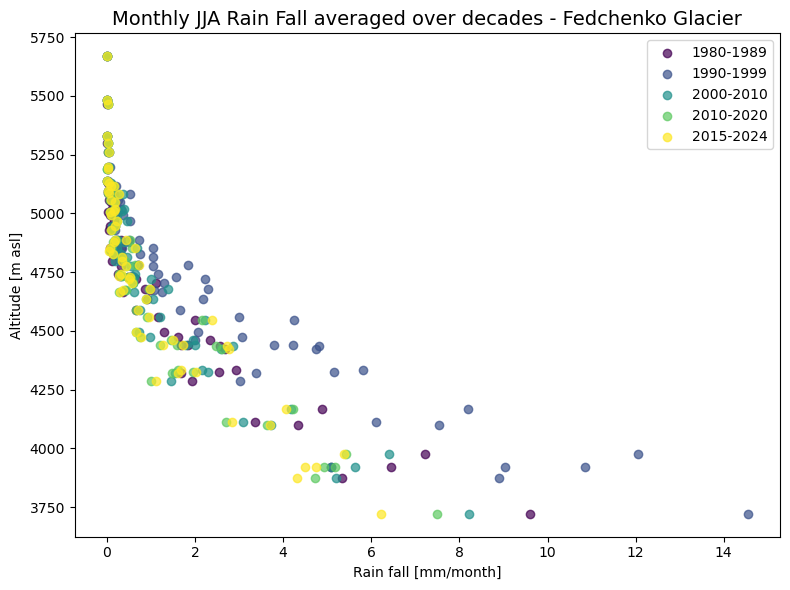

<Figure size 640x480 with 0 Axes>

In [38]:
seas = 'JJA'

plotname = f'{seas}_alti_RF_Fedchenko_MAR_GRp'

ds_SH_Fed_flat = ds_SH_Fed.mean(dim='time').values.flatten()

decade = ["1980-1989", "1990-1999", "2000-2010", "2010-2020", "2015-2024"]
param = ['1980','1990','2000','2010','2014']


ds_RF_Fed_dic = {
    "1980": ds_RF_Fed_1980_season.sel(season=seas),
    "1990": ds_RF_Fed_1990_season.sel(season=seas),
    "2000": ds_RF_Fed_2000_season.sel(season=seas),
    "2010": ds_RF_Fed_2010_season.sel(season=seas),
    "2014": ds_RF_Fed_2014_season.sel(season=seas),
}

cmap = cm.viridis  
n = len(param)
colors = [cmap(i/(n-1)) for i in range(n)]  

fig, ax = plt.subplots(figsize=(8, 6))

for i, key in enumerate(param):
    ax.scatter(
        ds_RF_Fed_dic[key].values.flatten(),
        ds_SH_Fed_flat,
        alpha=0.7,
        color=colors[i],
        label=decade[i],
        marker='o'
    )

ax.set_ylabel("Altitude [m asl]")
#ax.set_ylim(4400, 5800) 
ax.set_xlabel("Rain fall [mm/month]")
#ax.set_xlim(-0.2, 2) 
ax.legend()
ax.set_title(f"Monthly {seas} Rain Fall averaged over decades - Fedchenko Glacier", fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig(folder_figure + plotname + '.png', bbox_inches='tight')

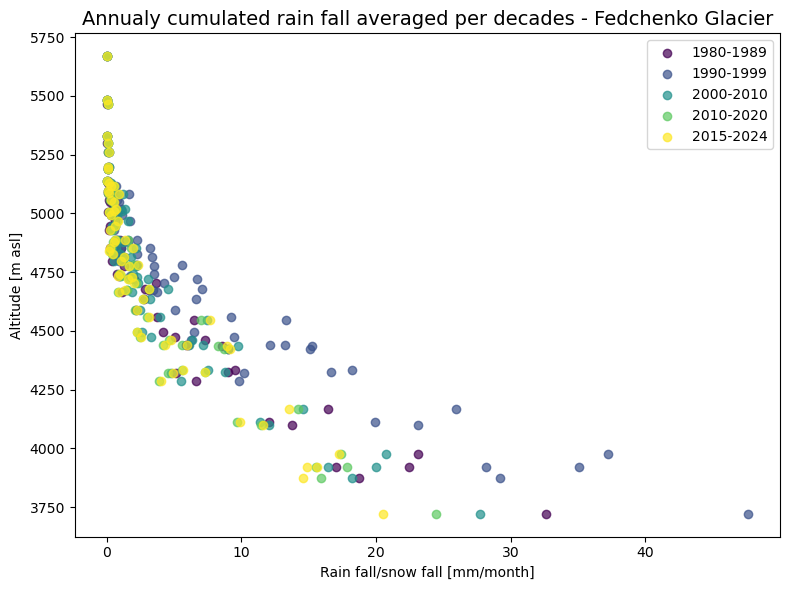

<Figure size 640x480 with 0 Axes>

In [39]:
plotname = f'Annual_alti_RF_Fedchenko_MAR_GRp'

ds_SH_Fed_flat = ds_SH_Fed.mean(dim='time').values.flatten()

decade = ["1980-1989", "1990-1999", "2000-2010", "2010-2020", "2015-2024"]
param = ['1980','1990','2000','2010','2014']

ds_RF_Fed_dic = {
    "1980": ds_RF_Fed_1980,
    "1990": ds_RF_Fed_1990,
    "2000": ds_RF_Fed_2000,
    "2010": ds_RF_Fed_2010,
    "2014": ds_RF_Fed_2014,
}

cmap = cm.viridis  
n = len(param)
colors = [cmap(i/(n-1)) for i in range(n)]  

fig, ax = plt.subplots(figsize=(8, 6))

for i, key in enumerate(param):
    ax.scatter(
        ds_RF_Fed_dic[key].groupby('time.year').sum(dim='time').mean(dim='year').values.flatten(),
        ds_SH_Fed_flat,
        alpha=0.7,
        color=colors[i],
        label=decade[i],
        marker='o'
    )

ax.set_ylabel("Altitude [m asl]")
#ax.set_ylim(4400, 5800) 
ax.set_xlabel("Rain fall/snow fall [mm/month]")
#ax.set_xlim(-0.2, 2) 
ax.legend()
ax.set_title(f"Annualy cumulated rain fall averaged per decades - Fedchenko Glacier", fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig(folder_figure + plotname + '.png', bbox_inches='tight')



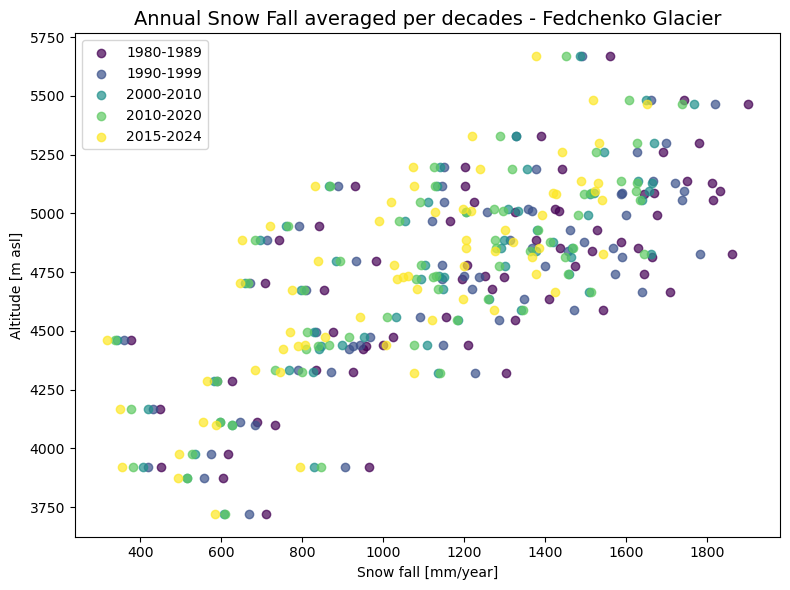

<Figure size 640x480 with 0 Axes>

In [40]:
plotname = f'annual_SF_Fedchenko_MAR_GRp'

ds_SH_Fed_flat = ds_SH_Fed.mean(dim='time').values.flatten()

decade = ["1980-1989", "1990-1999", "2000-2010", "2010-2020", "2015-2024"]
param = ['1980','1990','2000','2010','2014']

ds_SF_Fed_dic = {
    "1980": ds_SF_Fed_1980,
    "1990": ds_SF_Fed_1990,
    "2000": ds_SF_Fed_2000,
    "2010": ds_SF_Fed_2010,
    "2014": ds_SF_Fed_2014,
}

cmap = cm.viridis  
n = len(param)
colors = [cmap(i/(n-1)) for i in range(n)]  

fig, ax = plt.subplots(figsize=(8, 6))

for i, key in enumerate(param):
    ax.scatter(
        ds_SF_Fed_dic[key].groupby('time.year').sum(dim='time').mean(dim='year').values.flatten(),
        ds_SH_Fed_flat,
        alpha=0.7,
        color=colors[i],
        label=decade[i],
        marker='o'
    )

ax.set_ylabel("Altitude [m asl]")
#ax.set_ylim(4400, 5800) 
ax.set_xlabel("Snow fall [mm/year]")
#ax.set_xlim(-0.2, 2) 
ax.legend()
ax.set_title(f"Annual Snow Fall averaged per decades - Fedchenko Glacier", fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig(folder_figure + plotname + '.png', bbox_inches='tight')

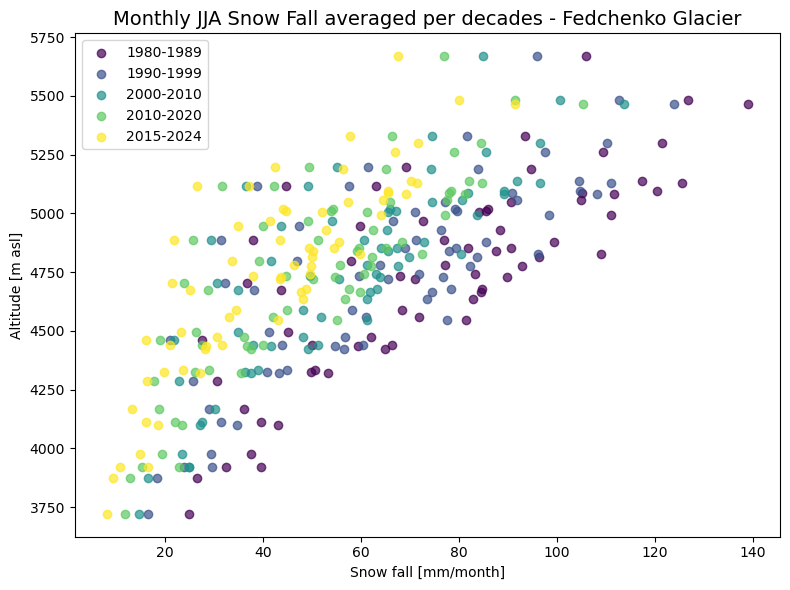

<Figure size 640x480 with 0 Axes>

In [41]:
plotname = f'{seas}_alti_RF_Fedchenko_MAR_GRp'

ds_SH_Fed_flat = ds_SH_Fed.mean(dim='time').values.flatten()

decade = ["1980-1989", "1990-1999", "2000-2010", "2010-2020", "2015-2024"]#,"2019-2024"]
param = ['1980','1990','2000','2010','2014']#,'2019']

seas = 'JJA'

ds_SF_Fed_dic = {
    "1980": ds_SF_Fed_1980_season.sel(season=seas),
    "1990": ds_SF_Fed_1990_season.sel(season=seas),
    "2000": ds_SF_Fed_2000_season.sel(season=seas),
    "2010": ds_SF_Fed_2010_season.sel(season=seas),
    "2014": ds_SF_Fed_2014_season.sel(season=seas),
#    "2019": ds_SF_Fed_2019_season.sel(season=seas),
}

cmap = cm.viridis  
n = len(param)
colors = [cmap(i/(n-1)) for i in range(n)]  

fig, ax = plt.subplots(figsize=(8, 6))

for i, key in enumerate(param):
    ax.scatter(
        ds_SF_Fed_dic[key].values.flatten(),
        ds_SH_Fed_flat,
        alpha=0.7,
        color=colors[i],
        label=decade[i],
        marker='o'
    )

ax.set_ylabel("Altitude [m asl]")
#ax.set_ylim(4400, 5800) 
ax.set_xlabel("Snow fall [mm/month]")
#ax.set_xlim(-0.2, 2) 
ax.legend()
ax.set_title(f"Monthly {seas} Snow Fall averaged per decades - Fedchenko Glacier", fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig(folder_figure + plotname + '.png', bbox_inches='tight')

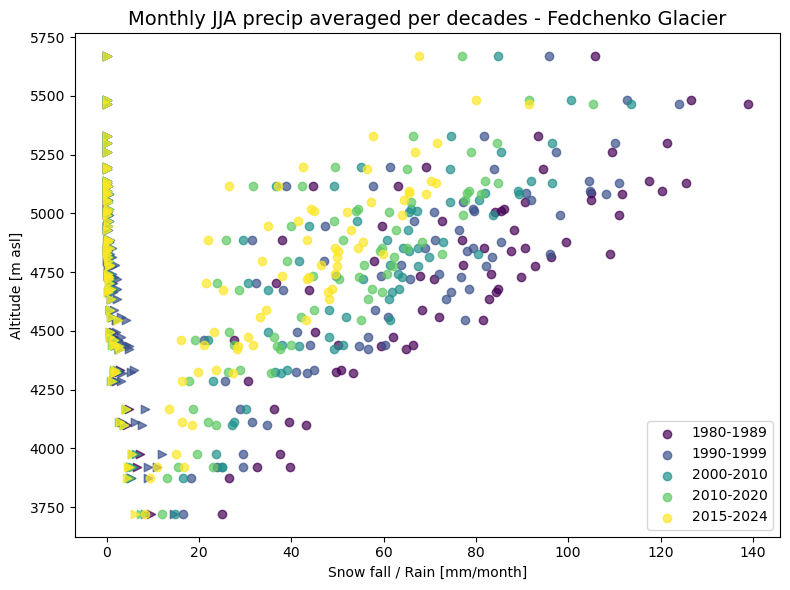

<Figure size 640x480 with 0 Axes>

In [42]:
seas = 'JJA'

plotname = f'{seas}_alti_Precip_Fedchenko_MAR_GRp'

ds_SH_Fed_flat = ds_SH_Fed.mean(dim='time').values.flatten()

decade = ["1980-1989", "1990-1999", "2000-2010", "2010-2020", "2015-2024"]#,"2019-2024"]
param = ['1980','1990','2000','2010','2014']#,'2019']

ds_SF_Fed_dic = {
    "1980": ds_SF_Fed_1980_season.sel(season=seas),
    "1990": ds_SF_Fed_1990_season.sel(season=seas),
    "2000": ds_SF_Fed_2000_season.sel(season=seas),
    "2010": ds_SF_Fed_2010_season.sel(season=seas),
    "2014": ds_SF_Fed_2014_season.sel(season=seas),
#    "2019": ds_SF_Fed_2019_season.sel(season=seas),
}
ds_RF_Fed_dic = {
    "1980": ds_RF_Fed_1980_season.sel(season=seas),
    "1990": ds_RF_Fed_1990_season.sel(season=seas),
    "2000": ds_RF_Fed_2000_season.sel(season=seas),
    "2010": ds_RF_Fed_2010_season.sel(season=seas),
    "2014": ds_RF_Fed_2014_season.sel(season=seas),
}


cmap = cm.viridis  
n = len(param)
colors = [cmap(i/(n-1)) for i in range(n)]  

fig, ax = plt.subplots(figsize=(8, 6))

for i, key in enumerate(param):
    ax.scatter(
        ds_SF_Fed_dic[key].values.flatten(),
        ds_SH_Fed_flat,
        alpha=0.7,
        color=colors[i],
        label=decade[i],
        marker='o'
    )
    ax.scatter(
        ds_RF_Fed_dic[key].values.flatten(),
        ds_SH_Fed_flat,
        alpha=0.7,
        color=colors[i],
#        label=decade[i],
        marker='>'
    )

ax.set_ylabel("Altitude [m asl]")
#ax.set_ylim(4400, 5800) 
ax.set_xlabel("Snow fall / Rain [mm/month]")
#ax.set_xlim(-0.2, 2) 
ax.legend()
ax.set_title(f"Monthly {seas} precip averaged per decades - Fedchenko Glacier", fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig(folder_figure + plotname + '.png', bbox_inches='tight')

/tmp/ipykernel_207763/574986491.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_by_elev = df.groupby('elev_bin')['data'].mean()
/tmp/ipykernel_207763/574986491.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_by_elev = df.groupby('elev_bin')['data'].mean()
/tmp/ipykernel_207763/574986491.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_by_elev = df.groupby('elev_bin')['data'].me

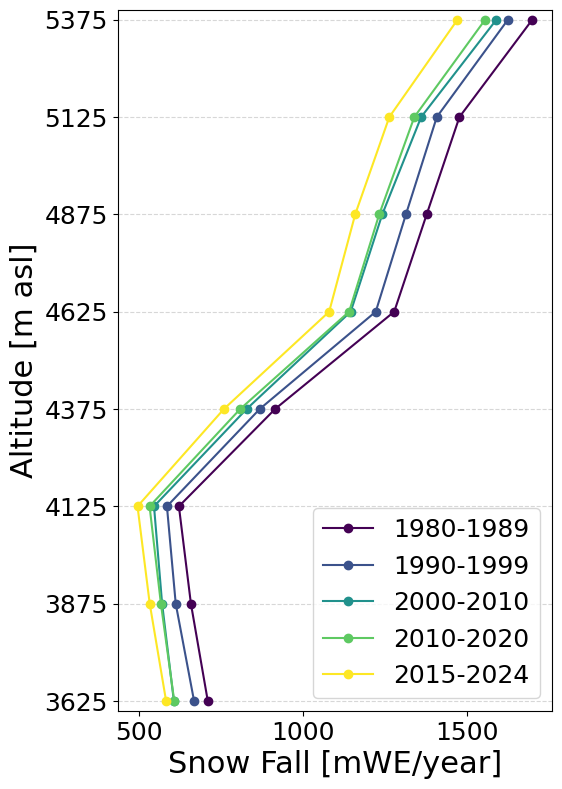

In [43]:
plotname = f'annual_binned_alti_SF_Fedchenko_MAR_GRp'

dsList = [
    ds_SF_Fed_1980,
    ds_SF_Fed_1990,
    ds_SF_Fed_2000,
    ds_SF_Fed_2010,
    ds_SF_Fed_2014
]

#il faut sommer sur year, puis moyenner les données annuelle
mean_data_by_elev_List = []

for elem in dsList:
    data_flat = elem.sum(dim='time').values.flatten()
    data_flat=data_flat/10 #on fait la somme de tous les SF mensuel, on divise par 10 
    #pour avoir une moyenne annuelle sur la décennie 
#    data_flat=data_flat/1000 #avoir un chiffre en m.
    df = pd.DataFrame({'elevation': ds_SH_Fed_flat, 'data': data_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_data_by_elev = df.groupby('elev_bin')['data'].mean()
    mean_data_by_elev_List.append(mean_data_by_elev)

###################################################################
decade = ["1980-1989", "1990-1999", "2000-2010", "2010-2020", "2015-2024"]
param = ['1980','1990','2000','2010','2014']

plt.rc('axes', titlesize=22, labelsize=22)   # titre et labels d'axes
plt.rc('xtick', labelsize=18)                # ticks en x
plt.rc('ytick', labelsize=18)                # ticks en y
plt.rc('legend', fontsize=18)                # légende
plt.rc('figure', titlesize=18)               # titre global (suptitle)


fig, ax = plt.subplots(figsize=(6, 8))
# Couleurs progressives
cmap = cm.viridis
n = len(param)
colors = [cmap(i/(n-1)) for i in range(n)]

# Tracé avec labels + couleurs
for i in range(len(dsList)):
    ax.plot(
        mean_data_by_elev_List[i].values,
        elev_bin_labels,
        marker='o',
        color=colors[i],
        label=decade[i]
    )

# Paramètres axes et légende
ax.set_yticks(elev_bin_labels)
ax.set_ylabel("Altitude [m asl]")
ax.set_ylim(3600, 5400)  
ax.set_xlabel("Snow Fall [mWE/year]")
#ax.xaxis.set_major_locator(1)
#ax.set_xlim(-4, 4)
#ax.set_title(f"Annual histo SMB over decades - Fedchenko Glacier", fontsize=14)
ax.legend()

ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.savefig('/home/fainx/'+plotname+'.png', bbox_inches='tight')

plt.tight_layout()
plt.show()


/tmp/ipykernel_207763/2183897320.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_by_elev = df.groupby('elev_bin')['data'].mean()
/tmp/ipykernel_207763/2183897320.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_by_elev = df.groupby('elev_bin')['data'].mean()
/tmp/ipykernel_207763/2183897320.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_by_elev = df.groupby('elev_bin')['data']

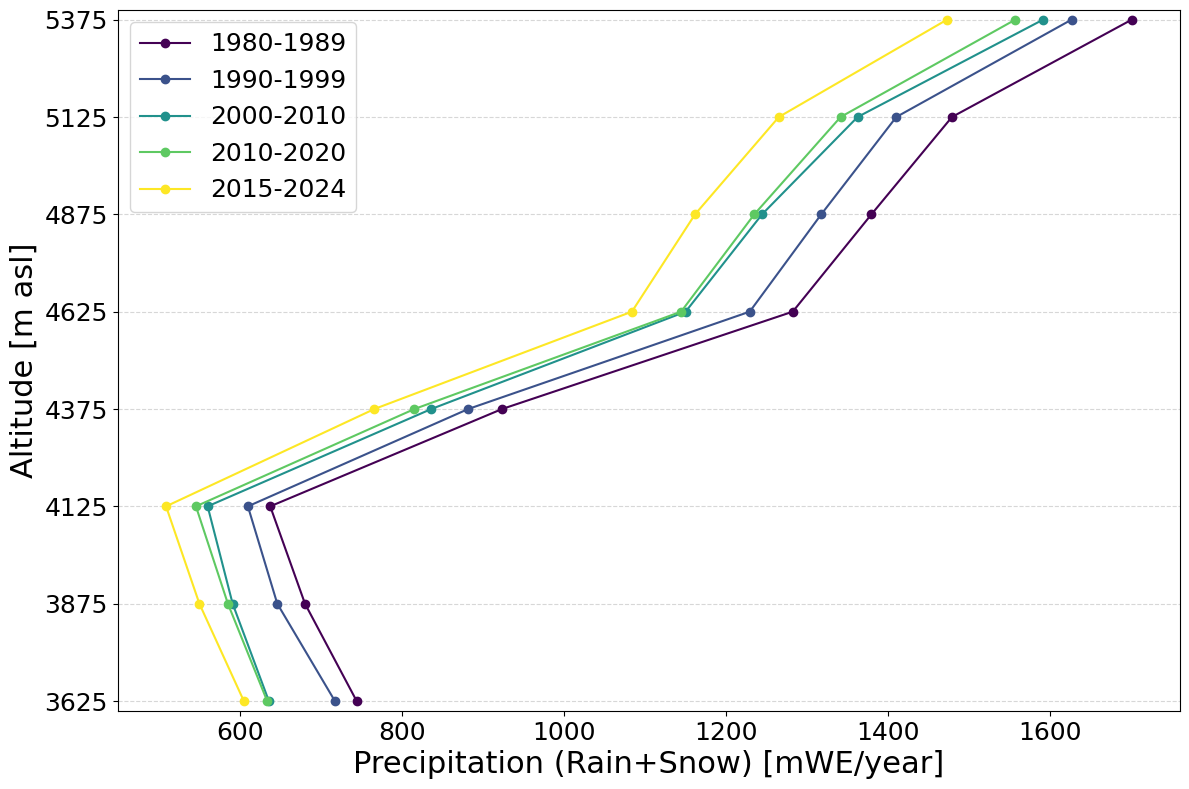

In [44]:
plotname = f'annual_binned_alti_SF_Fedchenko_MAR_GRp'

dsList = [
    ds_SF_Fed_1980+ds_RF_Fed_1980,
    ds_SF_Fed_1990+ds_RF_Fed_1990,
    ds_SF_Fed_2000+ds_RF_Fed_2000,
    ds_SF_Fed_2010+ds_RF_Fed_2010,
    ds_SF_Fed_2014+ds_RF_Fed_2014
]

#il faut sommer sur year, puis moyenner les données annuelle
mean_data_by_elev_List = []

for elem in dsList:
    data_flat = elem.sum(dim='time').values.flatten()
    data_flat=data_flat/10 #on fait la somme de tous les SF mensuel, on divise par 10 
    #pour avoir une moyenne annuelle sur la décennie 
#    data_flat=data_flat/1000 #avoir un chiffre en m.
    df = pd.DataFrame({'elevation': ds_SH_Fed_flat, 'data': data_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_data_by_elev = df.groupby('elev_bin')['data'].mean()
    mean_data_by_elev_List.append(mean_data_by_elev)

###################################################################
decade = ["1980-1989", "1990-1999", "2000-2010", "2010-2020", "2015-2024"]
param = ['1980','1990','2000','2010','2014']

plt.rc('axes', titlesize=22, labelsize=22)   # titre et labels d'axes
plt.rc('xtick', labelsize=18)                # ticks en x
plt.rc('ytick', labelsize=18)                # ticks en y
plt.rc('legend', fontsize=18)                # légende
plt.rc('figure', titlesize=18)               # titre global (suptitle)


fig, ax = plt.subplots(figsize=(12, 8))
# Couleurs progressives
cmap = cm.viridis
n = len(param)
colors = [cmap(i/(n-1)) for i in range(n)]

# Tracé avec labels + couleurs
for i in range(len(dsList)):
    ax.plot(
        mean_data_by_elev_List[i].values,
        elev_bin_labels,
        marker='o',
        color=colors[i],
        label=decade[i]
    )

# Paramètres axes et légende
ax.set_yticks(elev_bin_labels)
ax.set_ylabel("Altitude [m asl]")
ax.set_ylim(3600, 5400)  
ax.set_xlabel("Precipitation (Rain+Snow) [mWE/year]")
#ax.xaxis.set_major_locator(1)
#ax.set_xlim(-4, 4)
#ax.set_title(f"Annual histo SMB over decades - Fedchenko Glacier", fontsize=14)
ax.legend()

ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.savefig('/home/fainx/'+plotname+'.png', bbox_inches='tight')

plt.tight_layout()
plt.show()
